In [22]:
import os
import configparser
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image
from skimage.feature import hog
from skimage.color import rgb2gray
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [23]:
config = configparser.ConfigParser()
config.read('config.ini')

DATA_PATH    = config['DATA']['data_path']
IMAGE_SIZE   = int(config['DATA']['image_size'])
N_SAMPLES    = int(config['DATA']['n_samples'])
TRAIN_SIZE   = float(config['DATA']['train_size'])

KERNEL       = config['MODEL']['kernel']
C            = float(config['MODEL']['C'])
GAMMA        = config['MODEL']['gamma']
RANDOM_STATE = int(config['MODEL']['random_state'])

HOG_ORIENT   = int(config['FEATURES']['hog_orientations'])
HOG_PPC      = int(config['FEATURES']['hog_pixels_per_cell'])
HOG_CPB      = int(config['FEATURES']['hog_cells_per_block'])

MODEL_PATH   = config['PATHS']['model_path']
SCALER_PATH  = config['PATHS']['scaler_path']
TEST_PATH    = config['PATHS']['test_data_path']

In [24]:
n_each = N_SAMPLES // 2 

cat_files = sorted(glob(os.path.join(DATA_PATH, 'train', 'cat.*.jpg')))[:n_each]
dog_files = sorted(glob(os.path.join(DATA_PATH, 'train', 'dog.*.jpg')))[:n_each]

print(f'котики: {len(cat_files)}, собачики: {len(dog_files)}')

котики: 2500, собачики: 2500


In [25]:
def extract_hog_features(image_path, image_size, orientations, pixels_per_cell, cells_per_block):
    img = Image.open(image_path).convert('RGB').resize((image_size, image_size))
    img_array = np.array(img)
    img_gray = rgb2gray(img_array)
    features = hog(
        img_gray,
        orientations=orientations,
        pixels_per_cell=(pixels_per_cell, pixels_per_cell),
        cells_per_block=(cells_per_block, cells_per_block),
        block_norm='L2-Hys'
    )
    return features

In [ ]:
from tqdm import tqdm

all_files  = cat_files + dog_files
all_labels = [0] * len(cat_files) + [1] * len(dog_files)

X = []
for path in tqdm(all_files):
    feat = extract_hog_features(path, IMAGE_SIZE, HOG_ORIENT, HOG_PPC, HOG_CPB)
    X.append(feat)

X = np.array(X)
y = np.array(all_labels)

print({X.shape})  

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1 - TRAIN_SIZE,
    random_state=67,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}')

Train: (4000, 1764), Test: (1000, 1764)


In [ ]:
model = SVC(kernel=KERNEL, C=C, gamma=GAMMA, random_state=RANDOM_STATE, probability=True)
model.fit(X_train_scaled, y_train)

Обучаем SVM (kernel=rbf, C=1.0, gamma=scale)...
Обучение завершено за 107.9 сек


In [ ]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Cat', 'Dog']))

Accuracy: 0.7190 (71.90%)

Classification Report:
              precision    recall  f1-score   support

         Cat       0.71      0.73      0.72       500
         Dog       0.72      0.71      0.72       500

    accuracy                           0.72      1000
   macro avg       0.72      0.72      0.72      1000
weighted avg       0.72      0.72      0.72      1000



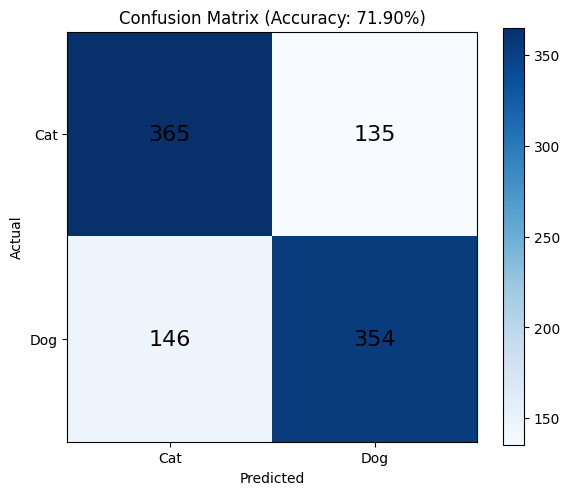

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Cat', 'Dog'])
ax.set_yticklabels(['Cat', 'Dog'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (Accuracy: {accuracy*100:.2f}%)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16)
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [ ]:
os.makedirs('experiments', exist_ok=True)

joblib.dump(model,  MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

joblib.dump({'X_test': X_test_scaled, 'y_test': y_test}, TEST_PATH)

Модель сохранена: experiments/model.pkl
Scaler сохранён: experiments/scaler.pkl
Тестовые данные сохранены: experiments/test_data.pkl
